In [1]:
import json
import time
from policytool import Certificate, PolicyGraph, PolicyReader, Prover, Thing

In [2]:
case_study_dir = 'tests/policies/case-study/'
things_dir = 'tests/things/'

In [3]:
things = []
certs = []
start_time = time.time()
with open('case_study.config') as config_file:
  config = json.load(config_file)
  for thing_json in config['things']:
    thing_pol = PolicyReader.read_policy_file(case_study_dir + thing_json['policy'])
    thing = Thing.from_file(things_dir + thing_json['file'], thing_pol)
    things.append(thing)
  for cert_json in config['certs']:
    cert_pol = PolicyReader.read_policy_file(case_study_dir + cert_json['policy'])
    cert = Certificate([cert_pol], cert_json['name'])
    certs.append(cert)
Prover.print_time(start_time)
print(f'Read {len(certs)} policy certificates and {len(things)} things.')

-- 0.0164s -- Read 18 policy certificates and 2 things.


In [4]:
start_time = time.time()
policy_graph = PolicyGraph(certs + things)
policy_graph.build_sym_graph()
Prover.print_time(start_time)
print(f'Built symbolic information flow graph of {policy_graph.size} nodes.')

-- 6.8736s -- Built symbolic information flow graph of 57 nodes.


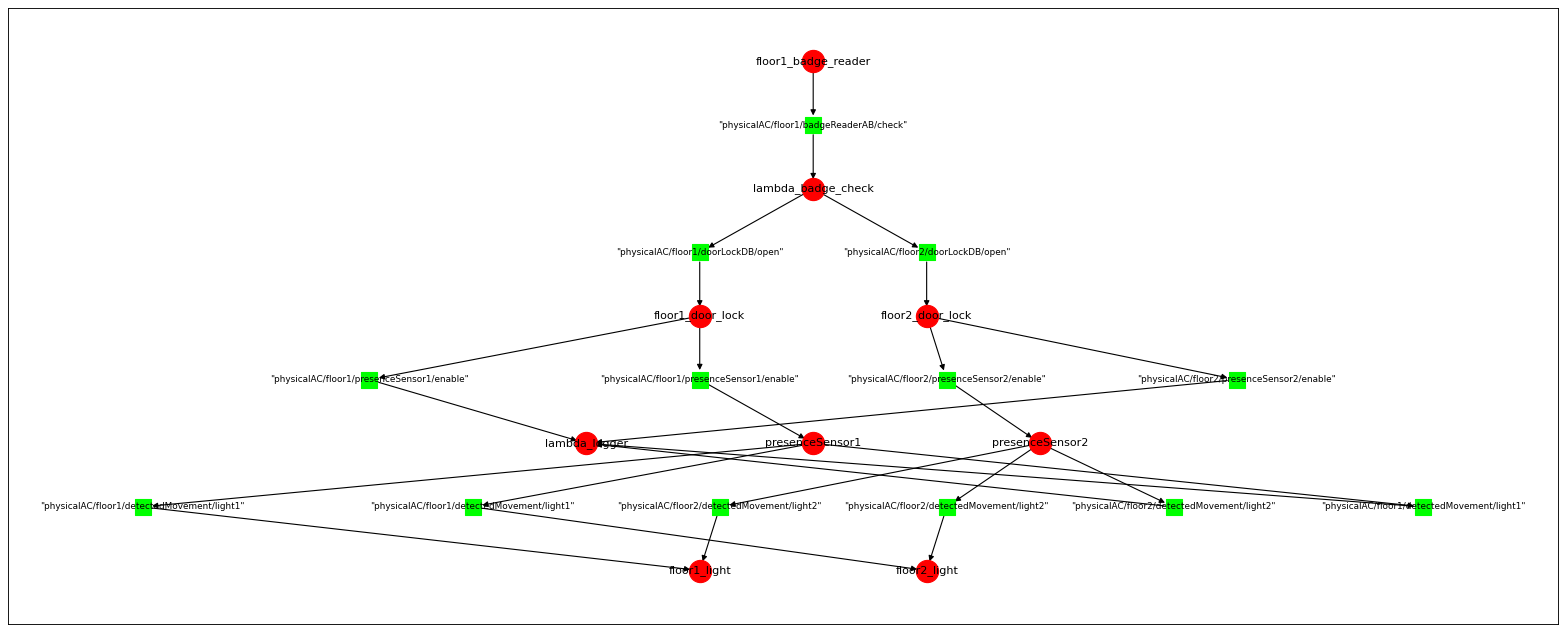

In [5]:
policy_graph.draw_tree(['floor1_badge_reader'])

In [6]:
prover = Prover(policy_graph.graph)
prover.reach('floor1_badge_reader', 'floor1_door_lock', log_level='info')
prover.reach('elevator', 'floor1_door_lock', log_level='info')
_ = ''

-- 0.0005s -- Found the path:
		 floor1_badge_reader
		 (badgeReaderAB) -> physicalAC/floor1/badgeReaderAB/check -> (lambdaBadgeCheck)
		 lambda_badge_check
		 (lambdaBadgeCheck) -> physicalAC/floor1/doorLockDB/open -> (doorLockDB)
		 floor1_door_lock
              from floor1_badge_reader to floor1_door_lock.
-- 0.0000s -- No path found from elevator to floor1_door_lock.


In [7]:
prover.reach_only('elevator', [], log_level='info')
prover.reach_only('lambda_fire_alarm', ['elevator', 'floor1_door_lock'], log_level='info')
prover.reach_only('elevator', ['lambda_fire_alarm'], log_level='info')
_ = ''

-- 0.0000s -- Checkin if elevator reaches only [].
-- 0.0005s -- Correct: elevator reaches only [].
-- 0.0000s -- Checkin if lambda_fire_alarm reaches only ['elevator', 'floor1_door_lock'].
-- 0.0000s -- Found the following unexpected paths (10):
		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (doorLockBA)
		 floor1_door_lock
		 (doorLockBA) -> physicalAC/floor1/presenceSensor1/enable -> (lambdaDoorLog)
		 lambda_logger

		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (pumpBA)
		 floor2_water_pump

		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (sirenAB)
		 floor2_fire_siren

		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (doorLockBA)
		 floor1_door_lock
		 (doorLockBA) -> physicalAC/floor1/presenceSensor1/enable -> (presenceSensor1)
		 presenceSensor1

		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (sirenAB)
		 floor1_fire_siren

		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (doorLockBA)
		 floor1

In [8]:
prover.only_reached_by('elevator', [
    'lambda_fire_alarm', 
    'floor1_smoke_sensor', 
    'floor2_smoke_sensor',
    'floor1_fire_alarm',
    'floor2_fire_alarm'
  ], log_level='info')
prover.only_reached_by('floor1_fire_siren', ['lambda_fire_alarm'], log_level='info')
prover.only_reached_by('floor1_light', ['lambda_fire_alarm'], log_level='info')
_ = ''

-- 0.0000s -- Checking if elevator is only reached by ['lambda_fire_alarm', 'floor1_smoke_sensor', 'floor2_smoke_sensor', 'floor1_fire_alarm', 'floor2_fire_alarm'].
-- 0.0005s -- Correct: elevator is only reached by ['lambda_fire_alarm', 'floor1_smoke_sensor', 'floor2_smoke_sensor', 'floor1_fire_alarm', 'floor2_fire_alarm'].
-- 0.0000s -- Checking if floor1_fire_siren is only reached by ['lambda_fire_alarm'].
-- 0.0000s -- Found the following unexpected paths (4):
		 floor2_smoke_sensor
		 (smokeSensorAB) -> fire/floor2/smokeLevels -> (lambdaFireAlarm)
		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (sirenAB)
		 floor1_fire_siren

		 floor1_fire_alarm
		 (fireAlarmBC) -> fire/detected -> (sirenDE)
		 floor1_fire_siren

		 floor2_fire_alarm
		 (fireAlarmBC) -> fire/detected -> (sirenDE)
		 floor1_fire_siren

		 floor1_smoke_sensor
		 (smokeSensorBA) -> fire/floor1/smokeLevels -> (lambdaFireAlarm)
		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (sirenAB)
		 fl

In [9]:
prover.isolated(['elevator'], ['floor1_light'], log_level='info')
prover.isolated(['lambda_fire_alarm', 'elevator', 'floor2_smoke_sensor'], 
                ['floor1_badge_reader', 'floor2_badge_reader'], log_level='info')
prover.isolated(['lambda_fire_alarm', 'elevator', 'floor2_smoke_sensor'], 
                ['floor1_light', 'floor2_light'], log_level='info')
_ = ''

-- 0.0000s -- Checking if the subsystems ['elevator'] and ['floor1_light'] are isolated.
-- 0.0000s -- The subsystems ['elevator'] and ['floor1_light'] are isolated
-- 0.0000s -- Checking if the subsystems ['lambda_fire_alarm', 'elevator', 'floor2_smoke_sensor'] and ['floor1_badge_reader', 'floor2_badge_reader'] are isolated.
-- 0.0005s -- The subsystems ['lambda_fire_alarm', 'elevator', 'floor2_smoke_sensor'] and ['floor1_badge_reader', 'floor2_badge_reader'] are isolated
-- 0.0000s -- Checking if the subsystems ['lambda_fire_alarm', 'elevator', 'floor2_smoke_sensor'] and ['floor1_light', 'floor2_light'] are isolated.
-- 0.0000s -- Not isolated since lambda_fire_alarm can reach floor1_light with the path:
-- 0.0000s -- Found the path:
		 lambda_fire_alarm
		 (lambdaFireAlarm) -> fire/detected -> (doorLockBA)
		 floor1_door_lock
		 (doorLockBA) -> physicalAC/floor1/presenceSensor1/enable -> (presenceSensor1)
		 presenceSensor1
		 (presenceSensor1) -> physicalAC/floor1/detectedMovement/